Chapter 19
# 聊聊Pandas
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
p = plt.rcParams
p["font.sans-serif"] = ["Roboto"]
p["font.weight"] = "light"
p["ytick.minor.visible"] = True
p["xtick.minor.visible"] = True
p["axes.grid"] = True
p["grid.color"] = "0.5"
p["grid.linewidth"] = 0.5

In [3]:
print(pd.__version__)

2.2.2


## 创建数据帧

In [ ]:
# 定义数据帧

### 从字典

In [4]:
# dict_eg = {'first_column':  ['first_value', 'second_value', ...],
#           'second_column':  ['first_value', 'second_value', ...],
#           'third_column':   ['first_value', 'second_value', ...],
#           ....}
# 采用默认行索引，Zero-based numbering
dict_eg = {'Positive integer': [1, 2, 3, 4, 5],
           'Greek letter': ['alpha', 'beta', 'gamma', 'delta', 'epsilon']}
df_from_dict = pd.DataFrame(data=dict_eg)
df_from_dict

,Positive integer,Greek letter
0,1,alpha
1,2,beta
2,3,gamma
3,4,delta
4,5,epsilon


In [5]:
df_from_dict2 = df_from_dict.set_index('Positive integer')
df_from_dict2

,Greek letter
Positive integer,
1,alpha
2,beta
3,gamma
4,delta
5,epsilon


In [6]:
df_from_dict2.reset_index()

,Positive integer,Greek letter
0,1,alpha
1,2,beta
2,3,gamma
3,4,delta
4,5,epsilon


In [7]:
# 修改行索引
df_from_dict3 = pd.DataFrame(data=dict_eg,
                             index = ['a', 'b', 'c', 'd', 'e'])
df_from_dict3

,Positive integer,Greek letter
a,1,alpha
b,2,beta
c,3,gamma
d,4,delta
e,5,epsilon


### 从列表

In [8]:
list_fruits = [['apple',  11],
               ['banana', 22],
               ['cherry', 33],
               ['durian', 44]]
df_from_list1 = pd.DataFrame(list_fruits) # 行列索引从0开始
df_from_list1

,0,1
0,apple,11
1,banana,22
2,cherry,33
3,durian,44


In [9]:
# 设定行索引
df_from_list1.set_axis(['a', 'b', 'c', 'd'], axis='index')

,0,1
a,apple,11
b,banana,22
c,cherry,33
d,durian,44


In [11]:
# 设定列标签
df_from_list1.set_axis(['Fruit', 'Number'], axis='columns')

,Fruit,Number
0,apple,11
1,banana,22
2,cherry,33
3,durian,44


### 改变row index

In [12]:
df_from_list2 = pd.DataFrame(list_fruits,
                            columns=['Fruit', 'Number'],
                            index = ['a', 'b', 'c', 'd'])
df_from_list2

,Fruit,Number
a,apple,11
b,banana,22
c,cherry,33
d,durian,44


### 将numpy数组转化为数据帧

In [13]:
numpy_array = np.random.normal(size = (10,4))
# NumPy库中的random.normal函数生成一个形状为(10, 4)的二维数组（矩阵），其中的元素是从正态分布（高斯分布）中随机抽取的数据。
df_from_np = pd.DataFrame(numpy_array,
                   columns=['X1', 'X2', 'X3', 'X4'])
df_from_np

,X1,X2,X3,X4
0,-0.888030,1.185454,0.737327,0.964830
1,-2.026998,-0.186071,-0.900894,-1.251744
2,1.026838,-1.595499,-1.362710,0.748629
3,2.237381,0.851092,-0.502219,-0.418272
4,-0.954085,-0.777712,-0.928865,0.341805
5,0.353320,0.395841,-1.914827,-1.293117
6,-1.363003,0.569325,0.654674,1.570504
7,0.671402,-0.126810,0.088271,-0.176499
8,-1.826551,0.279485,-0.639415,-0.159531
9,-0.354740,-0.261862,-0.748334,-1.276177


### for循环生成数据帧

In [14]:
np_data = []
# 创建一个空list
for idx in range(10):
    data_idx = np.random.normal(size = (1,4)).tolist()
    np_data.append(data_idx[0])

# 注意，用list.append() 速度相对较快
df_for_loop = pd.DataFrame(np_data,
                           columns = ['X1','X2','X3','X4'])
df_for_loop

,X1,X2,X3,X4
0,1.322119,-0.317159,0.175917,0.160027
1,-0.485251,-0.903034,-1.248813,-0.121179
2,0.236233,-0.121813,-1.726196,-0.613921
3,0.221989,0.189463,-0.304921,-1.590245
4,1.473225,-0.374284,-0.989317,-0.116497
5,0.454153,-0.194878,-0.725867,-1.041326
6,0.060854,0.023458,0.792297,-0.511937
7,-0.056238,0.019302,0.823932,-0.945478
8,-0.198192,1.521097,-0.383837,-1.610778
9,-0.241174,-0.375838,0.444269,-0.752264


In [15]:
data_idx[0]

[-0.24117419511653373,
 -0.3758375833183971,
 0.4442686695326146,
 -0.7522641472736491]

## 鸢尾花数据

In [16]:
iris_df = sns.load_dataset("iris")
# 从Seaborn中导入鸢尾花数据帧
iris_df.to_csv('iris_df.csv')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


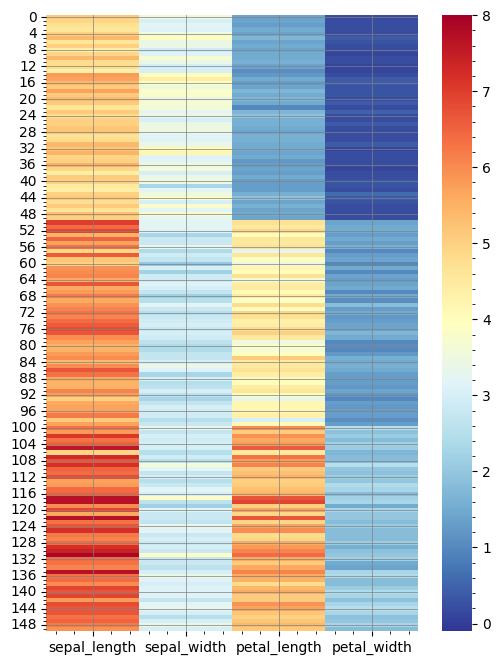

In [18]:
fig,ax = plt.subplots(figsize = (6,8))
sns.heatmap(iris_df.iloc[:, 0:4],
            cmap = 'RdYlBu_r',
            ax = ax,
            vmax = 0, vmin = 8,
            cbar_kws = {'orientation':'vertical'},
            annot=False)

fig.savefig('鸢尾花数据dataframe.svg', format='svg')

In [ ]:
# 打印整个数据集
print(iris_df.to_string())

In [ ]:
iris_df.to_numpy() # 将数据帧转化为NumPy array
# , dtype=object
# 在 NumPy 中，dtype=object 表示数组中的元素类型为 Python 对象。
# 这意味着数组的每个元素都可以是任意类型的 Python 对象，
# 例如整数、浮点数、字符串、列表、字典等。
# 与其他 NumPy 数组不同，dtype=object 数组允许每个元素具有不同的数据类型。

# 当你创建一个 NumPy 数组并指定 dtype=object，
# NumPy 将会把数组视为一个包含 Python 对象的数组，
# 而不是传统的数值类型数组。这种数组的灵活性较高，
# 但也会导致一些性能上的损失，
# 因为在处理数组时无法利用 NumPy 的优化和并行计算功能。

## 查询

In [22]:
# pandas.DataFrame.index
iris_df.index

RangeIndex(start=0, stop=150, step=1)

In [23]:
row_index_list = list(iris_df.index)
row_index_list

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149]

In [24]:
# pandas.DataFrame.columns
iris_df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [25]:
list(iris_df.columns)

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [26]:
# pandas.DataFrame.axes
iris_df.axes

[RangeIndex(start=0, stop=150, step=1),
 Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
        'species'],
       dtype='object')]

In [28]:
# 判断数据类型
type(iris_df)

pandas.core.frame.DataFrame

In [29]:
# 数据帧信息汇总
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# pandas.DataFrame.values
#用于返回数据帧中的实际数据部分作为一个多维 NumPy 数组。返回的数组可以
#用于进行数值计算、传递给其他库或以其他方式处理数据。
iris_df.values

In [31]:
# pandas.DataFrame.describe
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [32]:
# 小数点后一位
iris_df.describe().round(1)

,sepal_length,sepal_width,petal_length,petal_width
count,150.0,150.0,150.0,150.0
mean,5.8,3.1,3.8,1.2
std,0.8,0.4,1.8,0.8
min,4.3,2.0,1.0,0.1
25%,5.1,2.8,1.6,0.3
50%,5.8,3.0,4.4,1.3
75%,6.4,3.3,5.1,1.8
max,7.9,4.4,6.9,2.5


In [33]:
# pandas.DataFrame.nunique
iris_df.nunique()

,0
sepal_length,35
sepal_width,23
petal_length,43
petal_width,22
species,3


In [34]:
iris_df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [35]:
# 打印数据帧前5行
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [36]:
# 打印数据帧后5行
iris_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


### 形状

In [37]:
# 数据帧本质上就是一个表格
# 获取数据帧形状
# pandas.DataFrame.shape
iris_df.shape

(150, 5)

In [ ]:
# pandas.DataFrame.ndim

In [38]:
# 获取表格元素总数
# pandas.DataFrame.size
iris_df.size

750

In [39]:
# 每一列非缺失值的数量
# pandas.DataFrame.count
iris_df.count()

,0
sepal_length,150
sepal_width,150
petal_length,150
petal_width,150
species,150


In [40]:
print(iris_df.count(axis = 1))

0      5
1      5
2      5
3      5
4      5
      ..
145    5
146    5
147    5
148    5
149    5
Length: 150, dtype: int64


In [41]:
iris_df.count() * 100 / len(iris_df) # 没有缺失值

,0
sepal_length,100.0
sepal_width,100.0
petal_length,100.0
petal_width,100.0
species,100.0


In [42]:
# pandas.DataFrame.isnull
iris_df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [43]:
iris_df.isnull().sum() * 100 / len(iris_df)

,0
sepal_length,0.0
sepal_width,0.0
petal_length,0.0
petal_width,0.0
species,0.0


0      5
1      5
2      5
3      5
4      5
      ..
145    5
146    5
147    5
148    5
149    5
Length: 150, dtype: int64


In [44]:
# 获取数据帧行数，几种不同方法
print(iris_df.shape[0])
print(len(iris_df))
print(len(iris_df.index))
print(iris_df[iris_df.columns[0]].count())
num_rows = len(iris_df.axes[0])
num_rows

150
150
150
150


150

In [45]:
# 获取数据帧列数，几种不同方法
print(iris_df.shape[1])
print(len(iris_df.T))
print(len(iris_df.columns))
print(len(iris_df.axes[1]))

5
5
5
5


In [46]:
# 获得表头名称
iris_df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

### 循环

In [ ]:
# iterate rows
# 遍历数据帧的行
for idx, row_idx in iris_df.iterrows():
    print('=================')
    print('Row index =',str(idx))
    print(row_idx['sepal_length'], row_idx['sepal_width'])

=================</br>
Row index = 0
 --- 5.1 3.5</br>
=================</br>
Row index = 1
----4.9 3.0</br>
=================</br>
Row index = 2
----4.7 3.2</br>
=================</br>
Row index = 3
----4.6 3.1</br>

In [ ]:
# iterate column
# 遍历数据帧的列
for column_idx in iris_df:
    print(column_idx)
    print(iris_df[column_idx])


In [49]:
for column_idx in iris_df.iteritems():
    print(column_idx)


AttributeError: 'DataFrame' object has no attribute 'iteritems'

In [51]:
for column_idx in iris_df.items():
    print(column_idx)


('sepal_length', 0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64)
('sepal_width', 0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
145    3.0
146    2.5
147    3.0
148    3.4
149    3.0
Name: sepal_width, Length: 150, dtype: float64)
('petal_length', 0      1.4
1      1.4
2      1.3
3      1.5
4      1.4
      ... 
145    5.2
146    5.0
147    5.2
148    5.4
149    5.1
Name: petal_length, Length: 150, dtype: float64)
('petal_width', 0      0.2
1      0.2
2      0.2
3      0.2
4      0.2
      ... 
145    2.3
146    1.9
147    2.0
148    2.3
149    1.8
Name: petal_width, Length: 150, dtype: float64)
('species', 0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object)


### 转化

In [52]:
# 转置
iris_df.T

,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
sepal_length,5.1,4.9,4.7,4.6,5.0,5.4,4.6,5.0,4.4,4.9,...,6.7,6.9,5.8,6.8,6.7,6.7,6.3,6.5,6.2,5.9
sepal_width,3.5,3.0,3.2,3.1,3.6,3.9,3.4,3.4,2.9,3.1,...,3.1,3.1,2.7,3.2,3.3,3.0,2.5,3.0,3.4,3.0
petal_length,1.4,1.4,1.3,1.5,1.4,1.7,1.4,1.5,1.4,1.5,...,5.6,5.1,5.1,5.9,5.7,5.2,5.0,5.2,5.4,5.1
petal_width,0.2,0.2,0.2,0.2,0.2,0.4,0.3,0.2,0.2,0.1,...,2.4,2.3,1.9,2.3,2.5,2.3,1.9,2.0,2.3,1.8
species,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa,setosa,...,virginica,virginica,virginica,virginica,virginica,virginica,virginica,virginica,virginica,virginica


In [ ]:
# 将数据帧转化为numpy array
iris_df_2_array = iris_df.to_numpy()
iris_df_2_array

In [55]:
iris_df.columns[:4]

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [56]:
type(iris_df.columns[:4])

pandas.core.indexes.base.Index

In [54]:
# 数据帧前四列转化为numpy array
iris_df_2_array_numeric = iris_df[iris_df.columns[:4]].to_numpy() #iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
iris_df_2_array_numeric

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [57]:
iris_df_2_array_numeric.shape

(150, 4)

In [58]:
# 指定column名称，转化成numpy array
iris_df_2_array_sepal = iris_df[['sepal_length','sepal_width']].to_numpy()
iris_df_2_array_sepal

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

In [59]:
iris_df_2_array_sepal.shape

(150, 2)

### 更改表头

In [60]:
iris_df.rename(columns={'sepal_length': 'X1',
                        'sepal_width':  'X2',
                        'petal_length': 'X3',
                        'petal_width':  'X4',
                        'species':      'Y'})
# 注意，函数输入增加 inplace=True，直接修改原数据帧表头

,X1,X2,X3,X4,Y
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [61]:
# 另外两种新方法：
iris_df.rename({'sepal_length': 'X1',
                'sepal_width':  'X2',
                'petal_length': 'X3',
                'petal_width':  'X4',
                'species':      'Y'},
               axis = 1) # axis = 1;列方向

,X1,X2,X3,X4,Y
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [63]:
iris_df.rename({'sepal_length': 'X1',
                'sepal_width':  'X2',
                'petal_length': 'X3',
                'petal_width':  'X4',
                'species':      'Y'},
               axis = 'columns') # 直接指定 axis = 'columns'

,X1,X2,X3,X4,Y
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [64]:
# 加“根、缀”
iris_df_suffix = iris_df.add_suffix('_col') # 列标签加入标签
iris_df_suffix.head()

,sepal_length_col,sepal_width_col,petal_length_col,petal_width_col,species_col
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 修改行索引

In [65]:
iris_df.rename(lambda x: f'idx_{x}')

,sepal_length,sepal_width,petal_length,petal_width,species
idx_0,5.1,3.5,1.4,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
idx_145,6.7,3.0,5.2,2.3,virginica
idx_146,6.3,2.5,5.0,1.9,virginica
idx_147,6.5,3.0,5.2,2.0,virginica
idx_148,6.2,3.4,5.4,2.3,virginica


In [66]:
iris_df.rename(lambda x: f'{x}_idx') # 默认行

,sepal_length,sepal_width,petal_length,petal_width,species
0_idx,5.1,3.5,1.4,0.2,setosa
1_idx,4.9,3.0,1.4,0.2,setosa
2_idx,4.7,3.2,1.3,0.2,setosa
3_idx,4.6,3.1,1.5,0.2,setosa
4_idx,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145_idx,6.7,3.0,5.2,2.3,virginica
146_idx,6.3,2.5,5.0,1.9,virginica
147_idx,6.5,3.0,5.2,2.0,virginica
148_idx,6.2,3.4,5.4,2.3,virginica


In [67]:
iris_df_suffix.rename(columns = lambda x: x.strip('_col')) # 指定columns

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [68]:
iris_df_prefix = iris_df.add_prefix('col_').head() #加入前缀
iris_df_prefix

,col_sepal_length,col_sepal_width,col_petal_length,col_petal_width,col_species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


iris_df_suffix.rename(columns=lambda x: x.strip('_col')) 的意思是：对 DataFrame 的每一个列名，都执行 strip('_col') 操作，去掉列名字符串两端的 _col 字符（注意：是去掉两端的单个字符**，不是去掉整个子字符串 '_col'）。



```
 实验验证
s1 = "abc_col"
print(s1.strip('_col'))  # 输出 "ab" ？
# 实际输出： "ab"  ✅ 因为末尾的 '_col' 中的 _、c、o、l 都被删掉了

s2 = "__colX1_col__"
print(s2.strip('_col'))  # 输出 "X1" ？
# 实际输出： "X1"  ✅ 开头 _、_、c、o、l 被删掉，结尾 _、c、o、l 被删掉

s3 = "X1_col_suffix"
print(s3.strip('_col'))  # 输出 "X1_suffix" ？
# 实际输出： "X1_suffix"  ❌ 不对！因为中间有 'l'，但 strip 只删两端
# 实际是： 开头 'X' 不是 _、c、o、l，所以停止，结果还是 "X1_col_suffix"
```

重要结论：

strip('_col') 会删除 _、c、o、l 这四个字符（任意一个）

只删开头和结尾，不删中间

删除是逐个字符进行的，直到遇到不匹配的字符

In [69]:
iris_df_prefix.rename(columns = lambda x: x.strip('col_'))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 更改列顺序

In [70]:
# 当前列顺序
iris_df.columns.tolist()  #转为list

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [71]:
# 顺序调转
new_col_order = iris_df.columns.tolist()[::-1] # 倒序
new_col_order

['species', 'petal_width', 'petal_length', 'sepal_width', 'sepal_length']

In [73]:
iris_df[new_col_order] # 按照指定的索引重新排序

,species,petal_width,petal_length,sepal_width,sepal_length
0,setosa,0.2,1.4,3.5,5.1
1,setosa,0.2,1.4,3.0,4.9
2,setosa,0.2,1.3,3.2,4.7
3,setosa,0.2,1.5,3.1,4.6
4,setosa,0.2,1.4,3.6,5.0
...,...,...,...,...,...
145,virginica,2.3,5.2,3.0,6.7
146,virginica,1.9,5.0,2.5,6.3
147,virginica,2.0,5.2,3.0,6.5
148,virginica,2.3,5.4,3.4,6.2


In [74]:
# 自定义顺序
new_col_order = ['species',
                 'sepal_length', 'petal_length',
                 'sepal_width', 'petal_width']
iris_df[new_col_order]

,species,sepal_length,petal_length,sepal_width,petal_width
0,setosa,5.1,1.4,3.5,0.2
1,setosa,4.9,1.4,3.0,0.2
2,setosa,4.7,1.3,3.2,0.2
3,setosa,4.6,1.5,3.1,0.2
4,setosa,5.0,1.4,3.6,0.2
...,...,...,...,...,...
145,virginica,6.7,5.2,3.0,2.3
146,virginica,6.3,5.0,2.5,1.9
147,virginica,6.5,5.2,3.0,2.0
148,virginica,6.2,5.4,3.4,2.3


In [76]:
iris_df.reindex(columns=new_col_order) # 并不会修改元数据帧

,species,sepal_length,petal_length,sepal_width,petal_width
0,setosa,5.1,1.4,3.5,0.2
1,setosa,4.9,1.4,3.0,0.2
2,setosa,4.7,1.3,3.2,0.2
3,setosa,4.6,1.5,3.1,0.2
4,setosa,5.0,1.4,3.6,0.2
...,...,...,...,...,...
145,virginica,6.7,5.2,3.0,2.3
146,virginica,6.3,5.0,2.5,1.9
147,virginica,6.5,5.2,3.0,2.0
148,virginica,6.2,5.4,3.4,2.3


In [ ]:
iris_df

In [77]:
iris_df.loc[:, new_col_order]

,species,sepal_length,petal_length,sepal_width,petal_width
0,setosa,5.1,1.4,3.5,0.2
1,setosa,4.9,1.4,3.0,0.2
2,setosa,4.7,1.3,3.2,0.2
3,setosa,4.6,1.5,3.1,0.2
4,setosa,5.0,1.4,3.6,0.2
...,...,...,...,...,...
145,virginica,6.7,5.2,3.0,2.3
146,virginica,6.3,5.0,2.5,1.9
147,virginica,6.5,5.2,3.0,2.0
148,virginica,6.2,5.4,3.4,2.3


In [79]:
iris_df.iloc[:, [4,0,2,1,3]]

,species,sepal_length,petal_length,sepal_width,petal_width
0,setosa,5.1,1.4,3.5,0.2
1,setosa,4.9,1.4,3.0,0.2
2,setosa,4.7,1.3,3.2,0.2
3,setosa,4.6,1.5,3.1,0.2
4,setosa,5.0,1.4,3.6,0.2
...,...,...,...,...,...
145,virginica,6.7,5.2,3.0,2.3
146,virginica,6.3,5.0,2.5,1.9
147,virginica,6.5,5.2,3.0,2.0
148,virginica,6.2,5.4,3.4,2.3


In [81]:
iris_df.set_axis(new_col_order, axis=1) # 重新设置列标签；数据并没有发生改变

,species,sepal_length,petal_length,sepal_width,petal_width
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### 修改行顺序

In [82]:
# 取出前5行，并修改行索引
iris_df_ = iris_df.iloc[:5,:].rename(lambda x:
                                     f'idx_{x}')

In [83]:
iris_df_

,sepal_length,sepal_width,petal_length,petal_width,species
idx_0,5.1,3.5,1.4,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_4,5.0,3.6,1.4,0.2,setosa


In [84]:
new_order = ['idx_4','idx_2','idx_0','idx_3','idx_1']
iris_df_.reindex(new_order) # 默认行方向；axis=0

,sepal_length,sepal_width,petal_length,petal_width,species
idx_4,5.0,3.6,1.4,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_0,5.1,3.5,1.4,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa


In [86]:
iris_df_.loc[new_order] # 按照行标签获取数据

,sepal_length,sepal_width,petal_length,petal_width,species
idx_4,5.0,3.6,1.4,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_0,5.1,3.5,1.4,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa


In [87]:
new_order_int = [4, 2, 0, 3, 1]
iris_df_.iloc[new_order_int] # 位置索引获取数据

,sepal_length,sepal_width,petal_length,petal_width,species
idx_4,5.0,3.6,1.4,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_0,5.1,3.5,1.4,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa


In [89]:
iris_df_.sort_index() # 默认升序

,sepal_length,sepal_width,petal_length,petal_width,species
idx_0,5.1,3.5,1.4,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_4,5.0,3.6,1.4,0.2,setosa


In [90]:
iris_df_.sort_index(ascending=False) # 按照行标签排序；降序

,sepal_length,sepal_width,petal_length,petal_width,species
idx_4,5.0,3.6,1.4,0.2,setosa
idx_3,4.6,3.1,1.5,0.2,setosa
idx_2,4.7,3.2,1.3,0.2,setosa
idx_1,4.9,3.0,1.4,0.2,setosa
idx_0,5.1,3.5,1.4,0.2,setosa


### 删除特定行

In [92]:
iris_df.drop(index=[0,1]) # 删除1,2行数据
# 将inplace参数设置为True，可以在原地修改DataFrame，而不返回一个新的DataFrame

,sepal_length,sepal_width,petal_length,petal_width,species
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### 删除特定列

In [93]:
iris_df.drop(columns='species')

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 视图 vs 副本

In [94]:
df = pd.DataFrame({'A': [1, 2], 'B': [11, 22]})
df

,A,B
0,1,11
1,2,22


In [99]:
cc = df['A']  # 视图 view

In [103]:
cc.loc[[0,0]] = 3

In [104]:
cc

,A
0,3
1,2


In [105]:
df

,A,B
0,3,11
1,2,22


In [107]:
cc.loc[[0,0]] = 1

In [ ]:
df

In [109]:
df_view = df[['A']]  # 副本
df_view

,A
0,1
1,2


In [110]:
df_view.iloc[0,0] = 10

/tmp/ipykernel_434/2573417173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_view.iloc[0,0] = 10


In [111]:
df_view

,A
0,10
1,2


In [112]:
df

,A,B
0,1,11
1,2,22


## 时间序列

In [113]:
import pandas_datareader as pdr
import datetime

start_date = datetime.datetime(2014, 1, 1)
end_date   = datetime.datetime(2022, 12, 31)

ticker_list = ['SP500']
df = pdr.DataReader(ticker_list,
                    'fred',
                    start_date,
                    end_date)
df.to_csv('SP500_' + str(start_date.date()) + '_' + str(end_date.date()) + '.csv')
df.to_pickle('SP500_' + str(start_date.date()) + '_' + str(end_date.date()) + '.pkl')
# pandas.read_csv
# pandas.read_pickle

## 导入、导出文件

### 导出数据

In [114]:
# 将数据帧存成CSV文件
csv_filename = 'iris_df.csv'
iris_df.to_csv(csv_filename,
               index = False)
# 目前JupyterLab默认支持直接查看CSV数据，不需要任何插件
# 参考:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html

In [115]:
# 将数据帧存成Excel文件
xlsx_filename = 'iris_df.xlsx'
iris_df.to_excel(xlsx_filename,
                 sheet_name='iris_data')
#参考：
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_excel.html
# 数据帧还可以存成SQL、JSON、pickle等等格式

### 导入文件

In [ ]:
# 将导出的CSV、Excel文件再次读入

In [116]:
# 读入CSV文件
iris_df_from_CSV = pd.read_csv(csv_filename)
# 参考：
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

iris_df_from_CSV.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [117]:
# 读入Excel文件
iris_df_from_Excel = pd.read_excel(xlsx_filename)
# 参考：
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

iris_df_from_Excel.head()

,Unnamed: 0,sepal_length,sepal_width,petal_length,petal_width,species
0,0,5.1,3.5,1.4,0.2,setosa
1,1,4.9,3.0,1.4,0.2,setosa
2,2,4.7,3.2,1.3,0.2,setosa
3,3,4.6,3.1,1.5,0.2,setosa
4,4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Repo: https://github.com/Visualize-ML
# Book 1 Python for Beginners  |  From Basic Arithmetic to Machine Learning
# Published and copyrighted by Tsinghua University Press
# Beijing, China, 2023